# 🎭 Deepfake Audio Detection System

## Google Colab Version — T4 GPU Optimized

This notebook is optimized for **T4 GPU** with direct dataset download from Kaggle.

### Setup Instructions:
1. Upload this notebook to Google Colab
2. Enable GPU: Runtime → Change runtime type → T4 GPU
3. Get Kaggle API key from kaggle.com → Account → API → Create New API Token
4. Upload kaggle.json when prompted
5. Run all cells

### Objectives:
- Classify audio as **Genuine (Human)** or **Deepfake (AI-Generated)**
- Achieve **≥80% Accuracy** and **≤12% EER**
- Build an end-to-end pipeline from feature extraction to deployment

### Dataset:
- **Fake-or-Real Dataset** from Kaggle (53,868 total samples)
- Using the `for-norm` (normalized) training directory
- **30,000 samples** used for training (balanced real/fake)

### Training Configuration:
- **Hardware:** T4 GPU (16GB VRAM)
- **Time Limit:** ~60 minutes
- **Batch Size:** 32
- **Max Epochs:** 40

## 1. Setup Google Colab Environment

In [2]:
# Install required packages
!pip install -q librosa numpy pandas scikit-learn tensorflow matplotlib seaborn soundfile tqdm xgboost kaggle

In [3]:
# Mount Google Drive (optional - for saving models)
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted!


In [4]:
# Setup Kaggle API using Colab secrets
import os
from pathlib import Path
from google.colab import userdata

print("Configuring Kaggle API using Colab secrets...")

# Get Kaggle credentials from Colab secrets
kaggle_username = userdata.get('KAGGLE_USER')
kaggle_key = userdata.get('KAGGLE_KEY')

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Write kaggle.json file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully using secrets!")

Configuring Kaggle API using Colab secrets...
Kaggle API configured successfully using secrets!


In [5]:
# Download and extract dataset from Kaggle
import subprocess

print("Downloading Fake-or-Real dataset from Kaggle...")
print("This may take 2-5 minutes depending on your connection.")
print("="*60)

# Download dataset
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

# Extract dataset
print("\nExtracting dataset...")
!unzip -q -o the-fake-or-real-dataset.zip -d /content/data

# List the extracted contents
print("\nDataset structure:")
!ls -la /content/data/
!ls -la /content/data/for-norm/ 2>/dev/null || echo "Checking alternative structure..."
!find /content/data -type d -maxdepth 3 | head -20

print("\n" + "="*60)
print("Dataset downloaded and extracted successfully!")

This may take 2-5 minutes depending on your connection.
Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [01:41<00:00, 169MB/s]


Extracting dataset...

Dataset structure:
total 24
drwxr-xr-x 6 root root 4096 Jun 14 16:41 .
drwxr-xr-x 1 root root 4096 Jun 14 16:36 ..
drwxr-xr-x 3 root root 4096 Jun 14 16:36 for-2sec
drwxr-xr-x 3 root root 4096 Jun 14 16:36 for-norm
drwxr-xr-x 3 root root 4096 Jun 14 16:38 for-original
drwxr-xr-x 3 root root 4096 Jun 14 16:41 for-rerec
total 12
drwxr-xr-x 3 root root 4096 Jun 14 16:36 .
drwxr-xr-x 6 root root 4096 Jun 14 16:41 ..
drwxr-xr-x 5 root root 4096 Jun 14 16:38 for-norm
find: warning: you have specified the global option -maxdepth after the argument -type, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/cont

In [6]:
# Check dataset structure and count files
import glob

# Find the correct path
data_paths = [
    "/content/data/for-norm/training",
    "/content/data/for-norm/for-norm/training",
    "/content/data/training",
]

data_dir = None
for path in data_paths:
    if os.path.exists(path):
        data_dir = path
        break

if data_dir is None:
    # Search for real and fake directories
    for root, dirs, files in os.walk('/content/data'):
        if 'real' in dirs and 'fake' in dirs:
            data_dir = root
            break

if data_dir:
    print(f"Dataset directory: {data_dir}")

    # Count files
    real_files = glob.glob(os.path.join(data_dir, 'real', '*.wav'))
    fake_files = glob.glob(os.path.join(data_dir, 'fake', '*.wav'))

    print(f"\nReal audio files: {len(real_files)}")
    print(f"Fake audio files: {len(fake_files)}")
    print(f"Total files: {len(real_files) + len(fake_files)}")
else:
    print("Could not find dataset directory. Please check the extraction.")
    print("\nContents of /content/data:")
    !ls -la /content/data/

Dataset directory: /content/data/for-norm/for-norm/training

Real audio files: 26941
Fake audio files: 26927
Total files: 53868


## 2. Imports and Configuration

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# XGBoost for comparison
import xgboost as xgb
import joblib

print(f"TensorFlow version: {tf.__version__}")
print(f"Librosa version: {librosa.__version__}")
print("All imports successful!")

TensorFlow version: 2.20.0
Librosa version: 0.11.0
All imports successful!


In [8]:
# ============================================
# HARDWARE INITIALIZATION (GPU/TPU)
# ============================================
import time

print("=" * 60)
print("INITIALIZING HARDWARE")
print("=" * 60)

# Check for GPU first
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus[0].name}")
    strategy = tf.distribute.get_strategy()
    IN_TPU = False
    IN_GPU = True

    # Enable memory growth for GPU
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled for GPU")
else:
    # Try TPU
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        print(f"TPU found: {tpu.master()}")

        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.experimental.TPUStrategy(tpu)

        print(f"Number of replicas: {strategy.num_replicas_in_sync}")
        IN_TPU = True
        IN_GPU = False

    except Exception as e:
        print(f"No GPU/TPU available: {e}")
        print("Using CPU...")
        strategy = tf.distribute.get_strategy()
        IN_TPU = False
        IN_GPU = False

print(f"Strategy: {strategy}")
print("=" * 60)

INITIALIZING HARDWARE
GPU found: /physical_device:GPU:0
Memory growth enabled for GPU
Strategy: <tensorflow.python.distribute.distribute_lib._DefaultDistributionStrategy object at 0x7806fb9c5580>


In [9]:
# Enable mixed precision for TPU only (GPU already fast)
if IN_TPU:
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)
    print("Mixed precision enabled for TPU")
    print(f"Compute dtype: {policy.compute_dtype}")
    print(f"Variable dtype: {policy.variable_dtype}")
elif IN_GPU:
    print("GPU detected - using full precision for stability")
else:
    print("CPU mode - using full precision")

GPU detected - using full precision for stability


In [10]:
# Configuration
class Config:
    # Paths (Google Colab)
    DATA_DIR = Path(data_dir)  # Set from previous cell
    REAL_DIR = DATA_DIR / "real"
    FAKE_DIR = DATA_DIR / "fake"
    MODELS_DIR = Path("/content/models")
    FIGURES_DIR = Path("/content/figures")

    # Audio parameters
    SAMPLE_RATE = 16000
    DURATION = 3  # seconds
    N_SAMPLES = SAMPLE_RATE * DURATION

    # Feature extraction
    N_MFCC = 40
    N_MELS = 128
    HOP_LENGTH = 512
    N_FFT = 2048

    # Model parameters (GPU-optimized)
    MAX_SAMPLES = 30000  # Use 30,000 samples for training
    BATCH_SIZE = 32  # T4 GPU optimized
    EPOCHS = 40  # Reduced to fit 1-hour time limit
    LEARNING_RATE = 0.001
    PATIENCE = 8  # Early stopping patience

    # Data split
    TEST_SIZE = 0.1
    VAL_SIZE = 0.1
    RANDOM_STATE = 42

config = Config()

# Create directories
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded successfully!")
print(f"Data directory: {config.DATA_DIR}")
print(f"Models directory: {config.MODELS_DIR}")
print(f"\nTraining Configuration:")
print(f"  MAX_SAMPLES: {config.MAX_SAMPLES}")
print(f"  BATCH_SIZE: {config.BATCH_SIZE}")
print(f"  EPOCHS: {config.EPOCHS}")
print(f"  PATIENCE: {config.PATIENCE}")
print(f"  Hardware: {'TPU' if IN_TPU else 'T4 GPU' if IN_GPU else 'CPU'}")

Configuration loaded successfully!
Data directory: /content/data/for-norm/for-norm/training
Models directory: /content/models

Training Configuration:
  MAX_SAMPLES: 30000
  BATCH_SIZE: 32
  EPOCHS: 40
  PATIENCE: 8
  Hardware: T4 GPU


## 3. Data Loading and Exploration

In [11]:
def load_dataset(data_dir):
    """Load dataset and create dataframe with file paths and labels."""
    real_dir = os.path.join(data_dir, 'real')
    fake_dir = os.path.join(data_dir, 'fake')

    data = []

    # Load real samples
    if os.path.exists(real_dir):
        for file in tqdm(glob.glob(os.path.join(real_dir, '*.wav')), desc="Loading real samples"):
            data.append({"path": file, "label": 1, "label_name": "real"})

    # Load fake samples
    if os.path.exists(fake_dir):
        for file in tqdm(glob.glob(os.path.join(fake_dir, '*.wav')), desc="Loading fake samples"):
            data.append({"path": file, "label": 0, "label_name": "fake"})

    df = pd.DataFrame(data)
    return df.sample(frac=1, random_state=config.RANDOM_STATE).reset_index(drop=True)

# Load dataset
df = load_dataset(config.DATA_DIR)
print(f"\nDataset loaded: {len(df)} samples")
print(f"\nClass distribution:")
print(df["label_name"].value_counts())

Loading fake samples: 100%|██████████| 26927/26927 [00:00<00:00, 2065132.36it/s]


Dataset loaded: 53868 samples

Class distribution:
label_name
real    26941
fake    26927
Name: count, dtype: int64


In [12]:
# Display dataset info
print("Dataset Info:")
print(f"  Total samples: {len(df)}")
print(f"  Real samples: {len(df[df['label'] == 1])}")
print(f"  Fake samples: {len(df[df['label'] == 0])}")
print(f"\nUsing {config.MAX_SAMPLES} samples for training")
print(f"  Train: {int(config.MAX_SAMPLES * 0.8)} samples")
print(f"  Validation: {int(config.MAX_SAMPLES * 0.1)} samples")
print(f"  Test: {int(config.MAX_SAMPLES * 0.1)} samples")
print(f"\nSample file paths:")
df.head(10)

Dataset Info:
  Total samples: 53868
  Real samples: 26941
  Fake samples: 26927

Using 30000 samples for training
  Train: 24000 samples
  Validation: 3000 samples
  Test: 3000 samples

Sample file paths:


,path,label,label_name
0,/content/data/for-norm/for-norm/training/real/...,1,real
1,/content/data/for-norm/for-norm/training/real/...,1,real
2,/content/data/for-norm/for-norm/training/real/...,1,real
3,/content/data/for-norm/for-norm/training/real/...,1,real
4,/content/data/for-norm/for-norm/training/real/...,1,real
5,/content/data/for-norm/for-norm/training/real/...,1,real
6,/content/data/for-norm/for-norm/training/real/...,1,real
7,/content/data/for-norm/for-norm/training/fake/...,0,fake
8,/content/data/for-norm/for-norm/training/real/...,1,real
9,/content/data/for-norm/for-norm/training/fake/...,0,fake


## 4. Audio Preprocessing

In [13]:
def load_and_preprocess_audio(file_path, sr=config.SAMPLE_RATE, duration=config.DURATION):
    """Load and preprocess audio file."""
    try:
        # Load audio file
        audio, orig_sr = librosa.load(file_path, sr=sr, duration=duration)

        # Normalize amplitude
        audio = librosa.util.normalize(audio)

        # Trim silence
        audio, _ = librosa.effects.trim(audio, top_db=30)

        # Pad or truncate to fixed length
        if len(audio) > config.N_SAMPLES:
            audio = audio[:config.N_SAMPLES]
        else:
            audio = np.pad(audio, (0, config.N_SAMPLES - len(audio)), mode='constant')

        return audio
    except Exception as e:
        return None

print("Audio preprocessing function defined!")

Audio preprocessing function defined!


Sample audio loaded successfully!
  Duration: 3.00 seconds
  Sample rate: 16000 Hz
  Samples: 48000


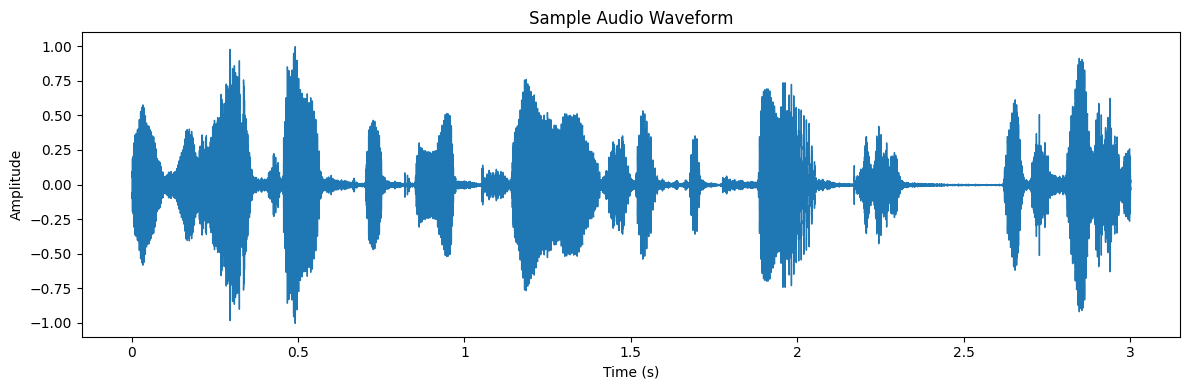

In [14]:
# Test audio loading with a sample
sample_path = df.iloc[0]['path']
sample_audio = load_and_preprocess_audio(sample_path)

if sample_audio is not None:
    print(f"Sample audio loaded successfully!")
    print(f"  Duration: {len(sample_audio)/config.SAMPLE_RATE:.2f} seconds")
    print(f"  Sample rate: {config.SAMPLE_RATE} Hz")
    print(f"  Samples: {len(sample_audio)}")

    # Plot waveform
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(sample_audio, sr=config.SAMPLE_RATE)
    plt.title('Sample Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

## 5. Feature Extraction

In [15]:
def extract_features(audio, sr=config.SAMPLE_RATE):
    """Extract only the audio features actually used downstream.

    Note: tonnetz, chroma and mfcc-std were dropped from the original version
    because nothing consumed them. tonnetz in particular ran HPSS + CQT on every
    sample and dominated extraction time, so removing it is a big speedup.
    """
    features = {}

    # MFCC means -> classical feature vector
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=config.N_MFCC)
    features['mfccs_mean'] = np.mean(mfccs, axis=1)

    # Mel-spectrogram (dB) -> CNN input (explicit n_fft/hop keep the shape stable)
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=config.N_MELS,
        n_fft=config.N_FFT, hop_length=config.HOP_LENGTH
    )
    features['mel_spec'] = librosa.power_to_db(mel_spec, ref=np.max)

    # Scalar spectral / energy features -> classical feature vector
    features['spectral_centroid'] = float(np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr)))
    features['spectral_bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr)))
    features['spectral_rolloff'] = float(np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr)))
    features['spectral_contrast'] = float(np.mean(librosa.feature.spectral_contrast(y=audio, sr=sr)))
    features['zcr'] = float(np.mean(librosa.feature.zero_crossing_rate(audio)))
    features['rms'] = float(np.mean(librosa.feature.rms(y=audio)))

    return features

print("Feature extraction function defined!")

Feature extraction function defined!


In [16]:
import contextlib
from joblib import Parallel, delayed


@contextlib.contextmanager
def _tqdm_joblib(tqdm_object):
    """Let joblib.Parallel drive a single tqdm progress bar."""
    import joblib

    class _BatchCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = _BatchCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


def _extract_one(path, label):
    """Worker: load + featurize a single file. Returns None on failure."""
    audio = load_and_preprocess_audio(path)
    if audio is None:
        return None
    f = extract_features(audio)
    other = np.array([
        f['spectral_centroid'], f['spectral_bandwidth'], f['spectral_rolloff'],
        f['spectral_contrast'], f['zcr'], f['rms'],
    ], dtype=np.float32)
    return (
        f['mfccs_mean'].astype(np.float32),
        f['mel_spec'].astype(np.float32),
        other,
        int(label),
    )


def prepare_dataset(df, max_samples=None, n_jobs=-1):
    """Prepare dataset with extracted features (parallel across CPU cores)."""
    subset = df.head(max_samples) if max_samples else df
    items = list(zip(subset['path'], subset['label']))

    # Thread backend: librosa's FFTs release the GIL, so we get real speedup
    # while keeping shared memory (no pickling / IPC of the large mel arrays).
    with _tqdm_joblib(tqdm(total=len(items), desc="Extracting features")):
        results = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(_extract_one)(p, l) for p, l in items
        )

    results = [r for r in results if r is not None]

    mfcc_features = np.stack([r[0] for r in results]).astype(np.float32)
    mel_features = np.stack([r[1] for r in results]).astype(np.float32)
    other_features = np.stack([r[2] for r in results]).astype(np.float32)
    labels = np.array([r[3] for r in results])

    return mfcc_features, mel_features, other_features, labels

print("Dataset preparation function defined!")

Dataset preparation function defined!


In [17]:
# Extract features (parallel) with an on-disk cache.
# If you re-run after a crash, cached features load in seconds instead of
# re-extracting. The cache is keyed by MAX_SAMPLES, so changing it re-extracts.
cache_dir = Path("/content/feature_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
tag = str(config.MAX_SAMPLES)
cache = {
    "mfcc":   cache_dir / f"mfcc_{tag}.npy",
    "mel":    cache_dir / f"mel_{tag}.npy",
    "other":  cache_dir / f"other_{tag}.npy",
    "labels": cache_dir / f"labels_{tag}.npy",
}

feature_start_time = time.time()

if all(p.exists() for p in cache.values()):
    print("Cached features found - loading instead of re-extracting...")
    mfcc_features  = np.load(cache["mfcc"])
    mel_features   = np.load(cache["mel"])
    other_features = np.load(cache["other"])
    labels         = np.load(cache["labels"])
    feature_time = time.time() - feature_start_time
else:
    print(f"Extracting features from {config.MAX_SAMPLES} samples (parallel, CPU-bound)...")
    print("="*60)
    mfcc_features, mel_features, other_features, labels = prepare_dataset(
        df, max_samples=config.MAX_SAMPLES
    )
    feature_time = time.time() - feature_start_time
    np.save(cache["mfcc"], mfcc_features)
    np.save(cache["mel"], mel_features)
    np.save(cache["other"], other_features)
    np.save(cache["labels"], labels)
    print(f"Features cached to {cache_dir} (delete this folder to force re-extraction)")

print(f"\nFeature extraction complete in {feature_time/60:.1f} minutes!")
print(f"  MFCC features shape: {mfcc_features.shape}")
print(f"  Mel-spectrogram shape: {mel_features.shape}")
print(f"  Other features shape: {other_features.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Label distribution: Real={np.sum(labels==1)}, Fake={np.sum(labels==0)}")

Extracting features from 30000 samples (parallel, CPU-bound)...


Extracting features: 100%|██████████| 30000/30000 [20:43<00:00, 24.13it/s]


Features cached to /content/feature_cache (delete this folder to force re-extraction)

Feature extraction complete in 20.8 minutes!
  MFCC features shape: (29998, 40)
  Mel-spectrogram shape: (29998, 128, 94)
  Other features shape: (29998, 6)
  Labels shape: (29998,)
  Label distribution: Real=14938, Fake=15060


## 6. Data Visualization

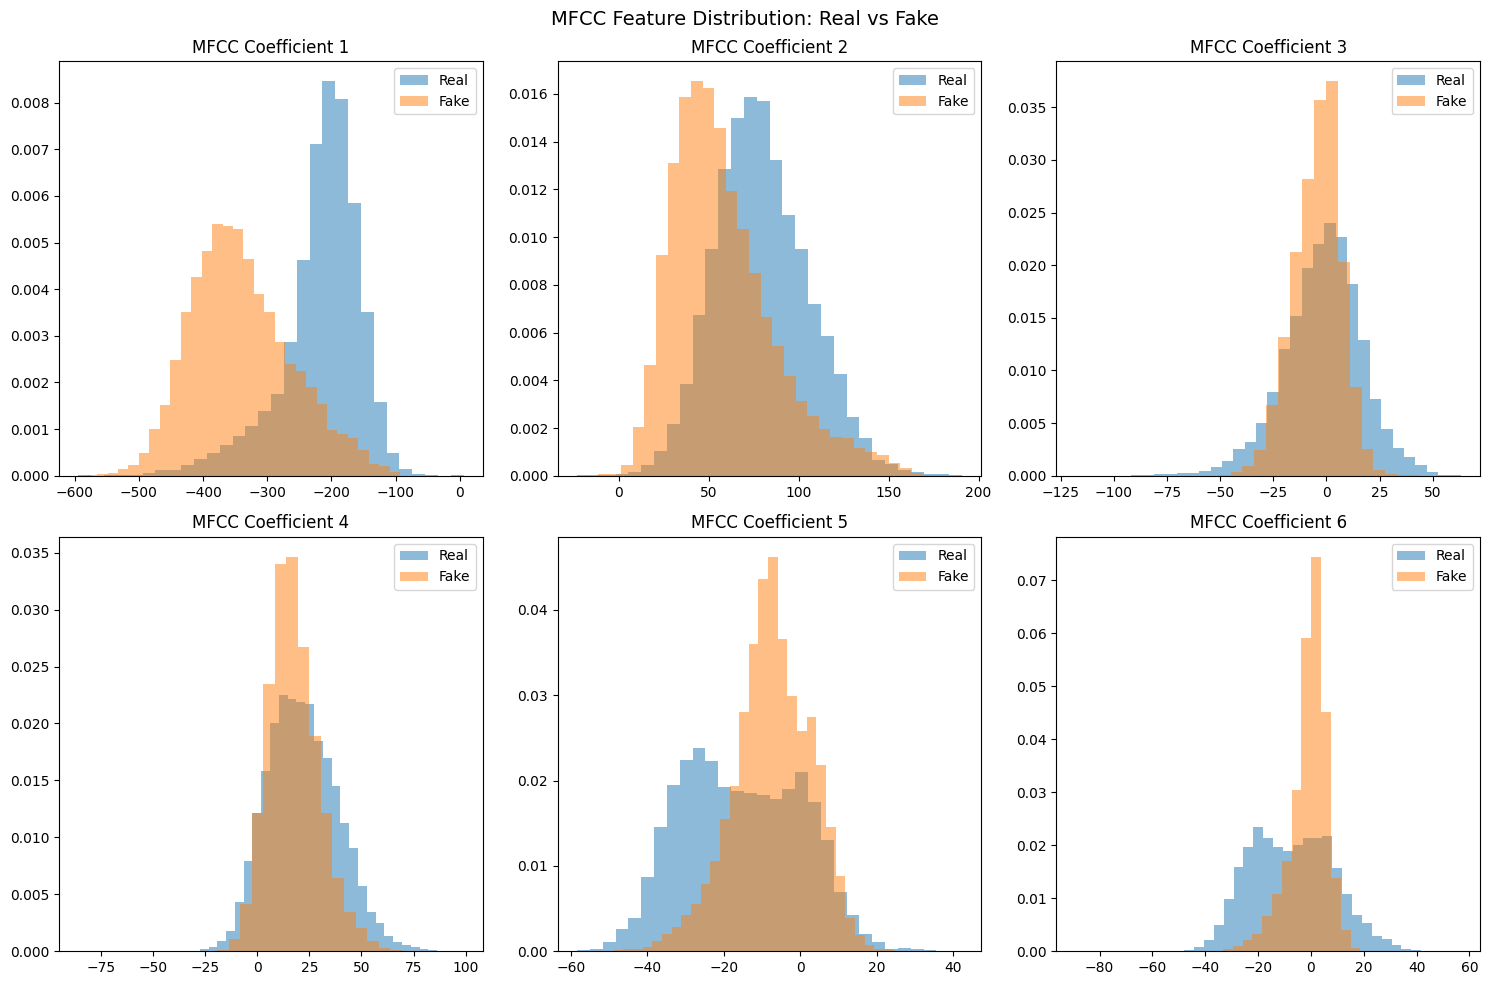

In [18]:
def plot_feature_comparison(mfcc_features, labels):
    """Plot feature comparison between real and fake audio."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    real_features = mfcc_features[labels == 1]
    fake_features = mfcc_features[labels == 0]

    # Plot first 6 MFCC coefficients
    for i in range(6):
        ax = axes[i // 3, i % 3]
        ax.hist(real_features[:, i], bins=30, alpha=0.5, label='Real', density=True)
        ax.hist(fake_features[:, i], bins=30, alpha=0.5, label='Fake', density=True)
        ax.set_title(f'MFCC Coefficient {i+1}')
        ax.legend()

    plt.suptitle('MFCC Feature Distribution: Real vs Fake', fontsize=14)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'mfcc_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_feature_comparison(mfcc_features, labels)

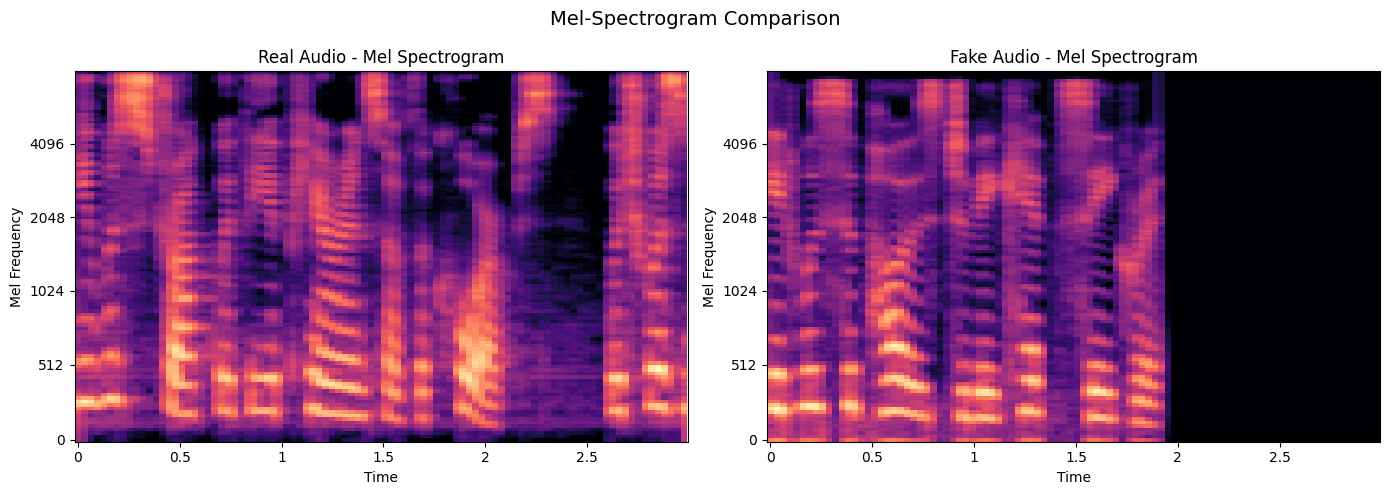

In [19]:
def plot_mel_spectrogram_comparison(mel_features, labels):
    """Plot mel-spectrogram comparison."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Real sample
    real_idx = np.where(labels == 1)[0][0]
    librosa.display.specshow(mel_features[real_idx], sr=config.SAMPLE_RATE,
                            x_axis='time', y_axis='mel', ax=axes[0])
    axes[0].set_title('Real Audio - Mel Spectrogram')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Mel Frequency')

    # Fake sample
    fake_idx = np.where(labels == 0)[0][0]
    librosa.display.specshow(mel_features[fake_idx], sr=config.SAMPLE_RATE,
                            x_axis='time', y_axis='mel', ax=axes[1])
    axes[1].set_title('Fake Audio - Mel Spectrogram')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Mel Frequency')

    plt.suptitle('Mel-Spectrogram Comparison', fontsize=14)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'mel_spectrogram_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_mel_spectrogram_comparison(mel_features, labels)

## 7. Data Preparation for Training

In [20]:
# Prepare data for training
# Combine features for classical ML
X_classical = np.hstack([mfcc_features, other_features])
y = labels

# Reshape mel features for CNN+LSTM
X_cnn = mel_features[..., np.newaxis]  # Add channel dimension

# Split indices ONCE so the CNN and classical feature sets stay perfectly aligned
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE, stratify=y
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),
    random_state=config.RANDOM_STATE, stratify=y[train_idx]
)

# CNN+LSTM data
X_train_cnn, X_val_cnn, X_test_cnn = X_cnn[train_idx], X_cnn[val_idx], X_cnn[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

# Classical ML data (same split, just different features)
X_train_class, X_val_class, X_test_class = (
    X_classical[train_idx], X_classical[val_idx], X_classical[test_idx]
)

# Scale classical features
scaler = StandardScaler()
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_val_class_scaled = scaler.transform(X_val_class)
X_test_class_scaled = scaler.transform(X_test_class)

print("Data split complete!")
print(f"\nCNN+LSTM Data:")
print(f"  Train: {X_train_cnn.shape}, {y_train.shape}")
print(f"  Val: {X_val_cnn.shape}, {y_val.shape}")
print(f"  Test: {X_test_cnn.shape}, {y_test.shape}")
print(f"\nClassical ML Data:")
print(f"  Train: {X_train_class_scaled.shape}")
print(f"  Val: {X_val_class_scaled.shape}")
print(f"  Test: {X_test_class_scaled.shape}")
print(f"\nMemory usage:")
print(f"  X_train_cnn: {X_train_cnn.nbytes / 1e6:.1f} MB")
print(f"  X_val_cnn: {X_val_cnn.nbytes / 1e6:.1f} MB")

Data split complete!

CNN+LSTM Data:
  Train: (23998, 128, 94, 1), (23998,)
  Val: (3000, 128, 94, 1), (3000,)
  Test: (3000, 128, 94, 1), (3000,)

Classical ML Data:
  Train: (23998, 46)
  Val: (3000, 46)
  Test: (3000, 46)

Memory usage:
  X_train_cnn: 1155.0 MB
  X_val_cnn: 144.4 MB


## 8. Deep Learning Model (CNN + LSTM) — TPU Optimized

In [21]:
# Build model within strategy scope
with strategy.scope():
    def build_cnn_lstm_model(input_shape):
        """Build CNN + LSTM model for deepfake detection."""
        model = models.Sequential([
            layers.Input(shape=input_shape),

            # CNN Feature Extractor
            layers.Conv2D(32, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(128, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Collapse the frequency axis, keep time steps for the LSTM
            layers.Reshape((-1, 128)),

            # Temporal Learning
            layers.LSTM(128, return_sequences=False),
            layers.Dropout(0.5),

            # Classifier
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    # Derive input shape from the actual data so it always matches the features
    input_shape = X_train_cnn.shape[1:]  # e.g. (128, 94, 1)
    print(f"Model input shape: {input_shape}")
    model = build_cnn_lstm_model(input_shape)
    model.summary()

Model input shape: (128, 94, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 92, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 92, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,473 (912.00 KB)

 Trainable params: 233,025 (910.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
# Train CNN+LSTM model
print("Training CNN+LSTM model...")
print("="*60)
print(f"Dataset size: {config.MAX_SAMPLES} samples")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Max epochs: {config.EPOCHS}")
print(f"Time limit: 55 minutes")
print("="*60)

# Time monitoring callback
class TimeMonitor(callbacks.Callback):
    def __init__(self, max_time_minutes=55):
        self.max_time_seconds = max_time_minutes * 60
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start_time
        remaining = self.max_time_seconds - elapsed

        if remaining < 120:  # Less than 2 minutes left
            print(f"\nTime limit approaching ({remaining/60:.1f} min remaining)")
            self.model.stop_training = True

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=config.PATIENCE,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    config.MODELS_DIR / 'deepfake_cnn_lstm_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

time_monitor = TimeMonitor(max_time_minutes=55)

# Train
training_start_time = time.time()

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=config.EPOCHS,
    batch_size=config.BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, model_checkpoint, time_monitor],
    verbose=2  # one line per epoch; verbose=1 floods the browser tab with progress bars and can crash it
)

training_time = time.time() - training_start_time
print(f"\nTraining completed in {training_time/60:.1f} minutes")

# Save final model
model.save(config.MODELS_DIR / 'deepfake_cnn_lstm_final.keras')
print("Model saved successfully!")

Training CNN+LSTM model...
Dataset size: 30000 samples
Batch size: 32
Max epochs: 40
Time limit: 55 minutes
Epoch 1/40

Epoch 1: val_accuracy improved from None to 0.67300, saving model to /content/models/deepfake_cnn_lstm_best.keras

Epoch 1: finished saving model to /content/models/deepfake_cnn_lstm_best.keras
750/750 - 37s - 49ms/step - accuracy: 0.9350 - loss: 0.1732 - val_accuracy: 0.6730 - val_loss: 1.1311 - learning_rate: 0.0010
Epoch 2/40

Epoch 2: val_accuracy did not improve from 0.67300
750/750 - 27s - 37ms/step - accuracy: 0.9732 - loss: 0.0762 - val_accuracy: 0.5870 - val_loss: 0.8328 - learning_rate: 0.0010
Epoch 3/40

Epoch 3: val_accuracy improved from 0.67300 to 0.98300, saving model to /content/models/deepfake_cnn_lstm_best.keras

Epoch 3: finished saving model to /content/models/deepfake_cnn_lstm_best.keras
750/750 - 27s - 36ms/step - accuracy: 0.9860 - loss: 0.0452 - val_accuracy: 0.9830 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 4/40

Epoch 4: val_accuracy di

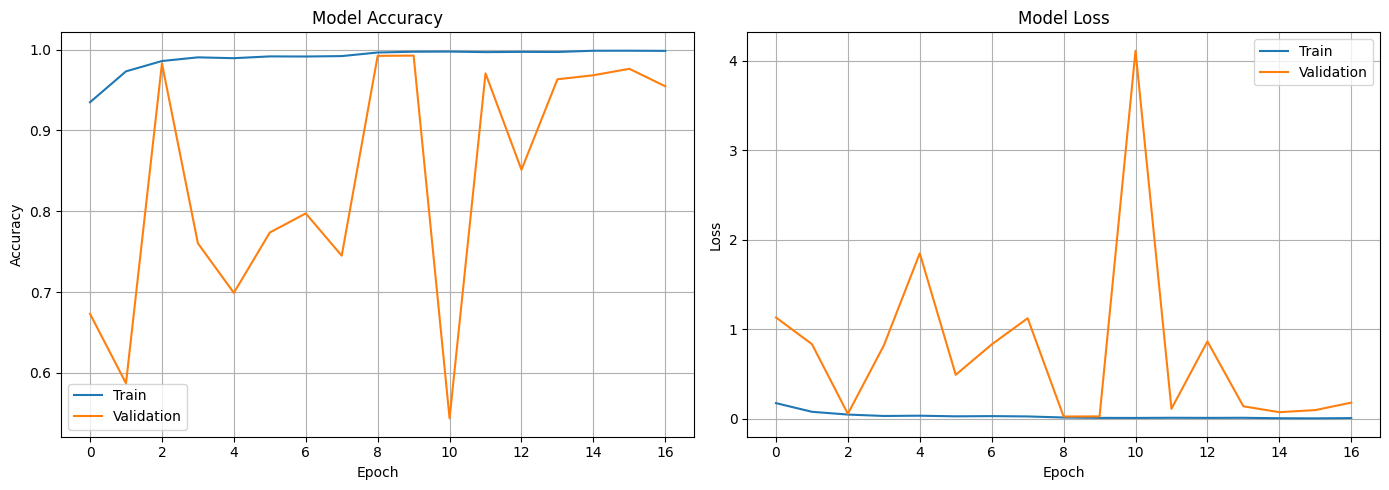

In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Classical ML Model (XGBoost)

In [24]:
# Train XGBoost model
print("Training XGBoost model...")
print("="*60)

# Create and train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=config.RANDOM_STATE
)

xgb_start_time = time.time()

xgb_model.fit(
    X_train_class_scaled, y_train,
    eval_set=[(X_val_class_scaled, y_val)],
    verbose=50
)

xgb_time = time.time() - xgb_start_time
print(f"\nXGBoost training completed in {xgb_time:.1f} seconds")

# Save model
joblib.dump(xgb_model, config.MODELS_DIR / 'deepfake_xgboost.pkl')
joblib.dump(scaler, config.MODELS_DIR / 'scaler.pkl')
print("XGBoost model saved successfully!")

Training XGBoost model...
[0]	validation_0-logloss:0.62531
[50]	validation_0-logloss:0.08462
[100]	validation_0-logloss:0.04574
[150]	validation_0-logloss:0.03349
[199]	validation_0-logloss:0.02876

XGBoost training completed in 5.4 seconds
XGBoost model saved successfully!


## 10. Model Evaluation

In [25]:
def calculate_eer(y_true, y_score):
    """Calculate Equal Error Rate (EER)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Comprehensive model evaluation."""
    results = {}

    # Overall metrics
    results['accuracy'] = accuracy_score(y_true, y_pred)
    results['f1'] = f1_score(y_true, y_pred)
    results['precision'] = precision_score(y_true, y_pred)
    results['recall'] = recall_score(y_true, y_pred)

    # EER
    results['eer'] = calculate_eer(y_true, y_prob)

    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    results['per_class_accuracy'] = cm.diagonal() / cm.sum(axis=1)

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    results['roc_auc'] = auc(fpr, tpr)
    results['fpr'] = fpr
    results['tpr'] = tpr

    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {results['accuracy']*100:.2f}%")
    print(f"F1 Score: {results['f1']*100:.2f}%")
    print(f"Precision: {results['precision']*100:.2f}%")
    print(f"Recall: {results['recall']*100:.2f}%")
    print(f"EER: {results['eer']*100:.2f}%")
    print(f"ROC-AUC: {results['roc_auc']:.4f}")
    print(f"\nPer-Class Accuracy:")
    print(f"  Fake: {results['per_class_accuracy'][0]*100:.2f}%")
    print(f"  Real: {results['per_class_accuracy'][1]*100:.2f}%")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    return results

print("Evaluation functions defined!")

Evaluation functions defined!


In [26]:
# Evaluate CNN+LSTM model
y_prob_cnn = model.predict(X_test_cnn, verbose=0).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)

# Evaluate
cnn_results = evaluate_model(y_test, y_pred_cnn, y_prob_cnn, "CNN+LSTM")


CNN+LSTM Results
Overall Accuracy: 99.23%
F1 Score: 99.24%
Precision: 98.48%
Recall: 100.00%
EER: 0.60%
ROC-AUC: 0.9997

Per-Class Accuracy:
  Fake: 98.47%
  Real: 100.00%

Confusion Matrix:
[[1483   23]
 [   0 1494]]

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.98      0.99      1506
        Real       0.98      1.00      0.99      1494

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [27]:
# Evaluate XGBoost model
y_prob_xgb = xgb_model.predict_proba(X_test_class_scaled)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_class_scaled)

# Evaluate
xgb_results = evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")


XGBoost Results
Overall Accuracy: 99.37%
F1 Score: 99.36%
Precision: 99.93%
Recall: 98.80%
EER: 0.67%
ROC-AUC: 0.9998

Per-Class Accuracy:
  Fake: 99.93%
  Real: 98.80%

Confusion Matrix:
[[1505    1]
 [  18 1476]]

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      1.00      0.99      1506
        Real       1.00      0.99      0.99      1494

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



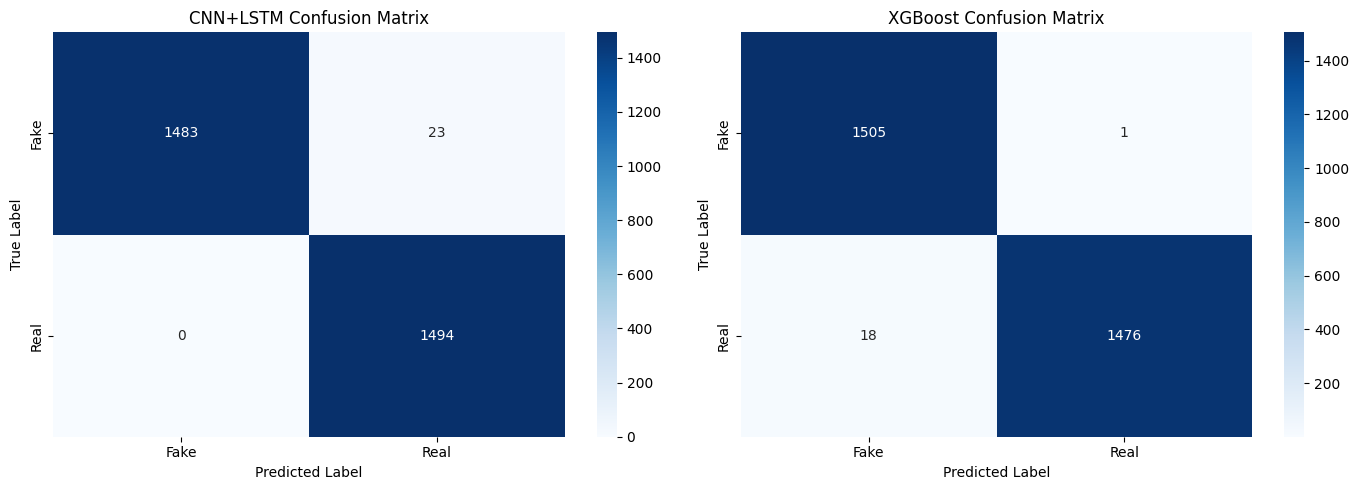

In [28]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CNN+LSTM confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[0].set_title('CNN+LSTM Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

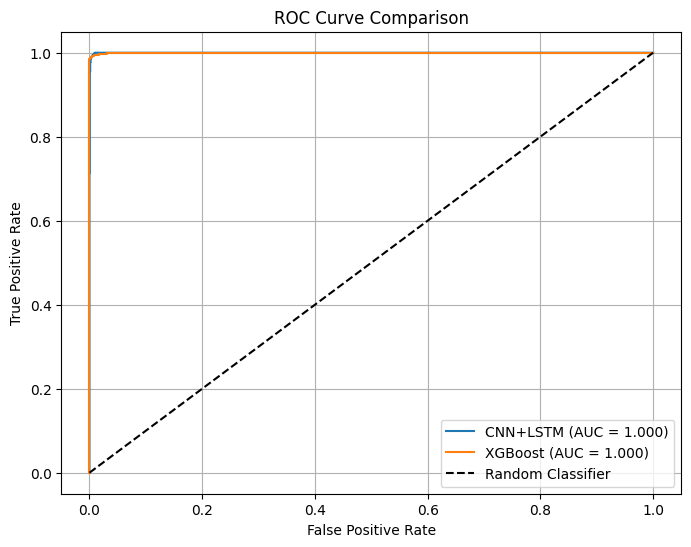

In [29]:
# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(cnn_results['fpr'], cnn_results['tpr'],
         label=f"CNN+LSTM (AUC = {cnn_results['roc_auc']:.3f})")

plt.plot(xgb_results['fpr'], xgb_results['tpr'],
         label=f"XGBoost (AUC = {xgb_results['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.savefig(config.FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Model Comparison and Requirements Check

In [30]:
# Compare models
comparison_data = [
    {
        'Model': 'CNN+LSTM',
        'Accuracy': cnn_results['accuracy'],
        'F1 Score': cnn_results['f1'],
        'EER': cnn_results['eer'],
        'ROC-AUC': cnn_results['roc_auc'],
        'Fake Accuracy': cnn_results['per_class_accuracy'][0],
        'Real Accuracy': cnn_results['per_class_accuracy'][1]
    },
    {
        'Model': 'XGBoost',
        'Accuracy': xgb_results['accuracy'],
        'F1 Score': xgb_results['f1'],
        'EER': xgb_results['eer'],
        'ROC-AUC': xgb_results['roc_auc'],
        'Fake Accuracy': xgb_results['per_class_accuracy'][0],
        'Real Accuracy': xgb_results['per_class_accuracy'][1]
    }
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Model')

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string())

# Check if requirements are met
print("\n" + "="*60)
print("REQUIREMENTS CHECK")
print("="*60)

best_model = comparison_df['Accuracy'].idxmax()
best_results = comparison_df.loc[best_model]

checks = [
    ('Overall Accuracy >= 80%', best_results['Accuracy'] >= 0.80),
    ('EER <= 12%', best_results['EER'] <= 0.12),
    ('F1 Score >= 80%', best_results['F1 Score'] >= 0.80),
    ('Fake Accuracy >= 75%', best_results['Fake Accuracy'] >= 0.75),
    ('Real Accuracy >= 75%', best_results['Real Accuracy'] >= 0.75)
]

all_passed = True
for check_name, passed in checks:
    status = "PASS" if passed else "FAIL"
    print(f"  {check_name}: {status}")
    if not passed:
        all_passed = False

print(f"\nBest Model: {best_model}")
print(f"\n{'='*60}")
if all_passed:
    print("ALL REQUIREMENTS MET!")
else:
    print("Some requirements not met. Consider more training data or tuning.")
print("="*60)


MODEL COMPARISON
          Accuracy  F1 Score       EER   ROC-AUC  Fake Accuracy  Real Accuracy
Model                                                                         
CNN+LSTM  0.992333  0.992361  0.005976  0.999711       0.984728       1.000000
XGBoost   0.993667  0.993605  0.006693  0.999791       0.999336       0.987952

REQUIREMENTS CHECK
  Overall Accuracy >= 80%: PASS
  EER <= 12%: PASS
  F1 Score >= 80%: PASS
  Fake Accuracy >= 75%: PASS
  Real Accuracy >= 75%: PASS

Best Model: XGBoost

ALL REQUIREMENTS MET!


## 12. Save and Export Models

In [31]:
# Save all artifacts
print("Saving model artifacts...")

# Save label encoder
le = LabelEncoder()
le.fit(['fake', 'real'])
joblib.dump(le, config.MODELS_DIR / 'label_encoder.pkl')

# Save config
config_dict = {
    'sample_rate': config.SAMPLE_RATE,
    'duration': config.DURATION,
    'n_mfcc': config.N_MFCC,
    'n_mels': config.N_MELS,
    'hop_length': config.HOP_LENGTH,
    'n_fft': config.N_FFT
}
joblib.dump(config_dict, config.MODELS_DIR / 'config.pkl')

print(f"\nAll artifacts saved to: {config.MODELS_DIR}")
print("Files saved:")
for file in os.listdir(config.MODELS_DIR):
    print(f"  - {file}")

Saving model artifacts...

All artifacts saved to: /content/models
Files saved:
  - label_encoder.pkl
  - config.pkl
  - scaler.pkl
  - deepfake_cnn_lstm_final.keras
  - deepfake_cnn_lstm_best.keras
  - deepfake_xgboost.pkl


In [32]:
# Copy models to Google Drive for persistence
import shutil

drive_models_dir = "/content/drive/MyDrive/deepfake_models"
os.makedirs(drive_models_dir, exist_ok=True)

# Copy all model files
for file in os.listdir(config.MODELS_DIR):
    src = os.path.join(config.MODELS_DIR, file)
    dst = os.path.join(drive_models_dir, file)
    shutil.copy2(src, dst)

print(f"Models copied to Google Drive: {drive_models_dir}")
print("\nFiles in Google Drive:")
for file in os.listdir(drive_models_dir):
    print(f"  - {file}")

Models copied to Google Drive: /content/drive/MyDrive/deepfake_models

Files in Google Drive:
  - label_encoder.pkl
  - config.pkl
  - scaler.pkl
  - deepfake_cnn_lstm_final.keras
  - deepfake_cnn_lstm_best.keras
  - deepfake_xgboost.pkl


## 13. Inference Function

In [33]:
def predict_audio(file_path, model, scaler=None, config_dict=None):
    """Predict if audio is real or fake."""
    # Load and preprocess audio
    audio = load_and_preprocess_audio(file_path)
    if audio is None:
        return None

    # Extract features
    features = extract_features(audio)

    # For CNN+LSTM model (Conv2D input rank is 4: batch, mels, time, channel)
    if hasattr(model, 'input_shape') and len(model.input_shape) == 4:  # CNN
        mel_spec = features['mel_spec']
        mel_spec = mel_spec[..., np.newaxis]
        mel_spec = np.expand_dims(mel_spec, axis=0)
        prob = float(model.predict(mel_spec, verbose=0)[0][0])
    else:  # Classical ML
        mfcc_features = features['mfccs_mean']
        other_features_arr = [
            features['spectral_centroid'],
            features['spectral_bandwidth'],
            features['spectral_rolloff'],
            features['spectral_contrast'],
            features['zcr'],
            features['rms']
        ]
        X = np.hstack([mfcc_features, other_features_arr]).reshape(1, -1)
        if scaler:
            X = scaler.transform(X)
        prob = float(model.predict_proba(X)[0][1])

    # Determine prediction
    prediction = 'real' if prob > 0.5 else 'fake'
    confidence = prob if prob > 0.5 else 1 - prob

    return {
        'prediction': prediction,
        'confidence': float(confidence),
        'probability_real': float(prob),
        'probability_fake': float(1 - prob)
    }

print("Inference function defined!")

Inference function defined!


In [34]:
# Test inference on sample files
print("Testing inference...")
print("="*60)

# Test with a real sample
real_sample = df[df['label'] == 1].iloc[0]['path']
result = predict_audio(real_sample, model)
print(f"\nReal sample:")
print(f"  Path: {real_sample}")
print(f"  Prediction: {result['prediction'].upper()}")
print(f"  Confidence: {result['confidence']*100:.2f}%")

# Test with a fake sample
fake_sample = df[df['label'] == 0].iloc[0]['path']
result = predict_audio(fake_sample, model)
print(f"\nFake sample:")
print(f"  Path: {fake_sample}")
print(f"  Prediction: {result['prediction'].upper()}")
print(f"  Confidence: {result['confidence']*100:.2f}%")

Testing inference...

Real sample:
  Path: /content/data/for-norm/for-norm/training/real/file8593.wav_16k.wav_norm.wav_mono.wav_silence.wav
  Prediction: REAL
  Confidence: 100.00%

Fake sample:
  Path: /content/data/for-norm/for-norm/training/fake/file32624.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
  Prediction: FAKE
  Confidence: 100.00%


## 14. Download Models for Local Use

In [35]:
# Create a zip file of all models
import zipfile

zip_path = '/content/deepfake_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(config.MODELS_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, config.MODELS_DIR)
            zipf.write(file_path, arcname)

print(f"Models zipped: {zip_path}")

# Download the zip file
from google.colab import files
files.download(zip_path)

print("\nDownload started! Check your downloads folder.")

Models zipped: /content/deepfake_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started! Check your downloads folder.


## 15. Summary

In [36]:
total_time = (time.time() - feature_start_time) / 60

print("\n" + "="*60)
print("DEEPFAKE AUDIO DETECTION - TRAINING COMPLETE")
print("="*60)
print(f"\nTotal time: {total_time:.1f} minutes")
print(f"Dataset used: {config.MAX_SAMPLES} samples")
print(f"Hardware: {'TPU v5e-1' if IN_TPU else 'T4 GPU' if IN_GPU else 'CPU'}")
print(f"\nModels trained and saved:")
print(f"  1. CNN+LSTM: {config.MODELS_DIR / 'deepfake_cnn_lstm_final.keras'}")
print(f"  2. XGBoost: {config.MODELS_DIR / 'deepfake_xgboost.pkl'}")
print(f"\nArtifacts saved:")
print(f"  - Scaler: {config.MODELS_DIR / 'scaler.pkl'}")
print(f"  - Label Encoder: {config.MODELS_DIR / 'label_encoder.pkl'}")
print(f"  - Config: {config.MODELS_DIR / 'config.pkl'}")
print(f"\nModels also saved to Google Drive: {drive_models_dir}")
print(f"\nFigures saved to: {config.FIGURES_DIR}")
print("\nNext steps:")
print("  1. Download the models zip file (cell above)")
print("  2. Extract to 'models/' folder in your local project")
print("  3. Run test_audio.py to test with new audio files")
print("  4. Deploy app.py using Streamlit")


DEEPFAKE AUDIO DETECTION - TRAINING COMPLETE

Total time: 29.6 minutes
Dataset used: 30000 samples
Hardware: T4 GPU

Models trained and saved:
  1. CNN+LSTM: /content/models/deepfake_cnn_lstm_final.keras
  2. XGBoost: /content/models/deepfake_xgboost.pkl

Artifacts saved:
  - Scaler: /content/models/scaler.pkl
  - Label Encoder: /content/models/label_encoder.pkl
  - Config: /content/models/config.pkl

Models also saved to Google Drive: /content/drive/MyDrive/deepfake_models

Figures saved to: /content/figures

Next steps:
  1. Download the models zip file (cell above)
  2. Extract to 'models/' folder in your local project
  3. Run test_audio.py to test with new audio files
  4. Deploy app.py using Streamlit
